#NMD and Coding Potential

Analyze NMD-targeted isoforms and coding potential across cell types and tissues (recollapsed counts).

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from add_classification import add_classification

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#1. Load pbids h5ad with classification metadata

In [3]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad")
from add_classification import add_classification
add_classification(adata, "./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                   isoform_col="molecule_id", prefix="pigeon_", sep=",")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")
print(f"Var columns: {list(adata.var.columns)}")

print(f"Unique cell ontology classes: {(adata.obs['cell_ontology_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['cell_ontology_class'].nunique() - int((adata.obs['cell_ontology_class'] == 'unknown').any())} unique")
print(f"Unique broad cell classes: {(adata.obs['broad_cell_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['broad_cell_class'].nunique() - int((adata.obs['broad_cell_class'] == 'unknown').any())} unique")

if "tissue" not in adata.obs.columns:
    parts = adata.obs.index.str.split("_")
    adata.obs["tissue"] = ["_".join(p[1:]) if len(p) > 1 else "unknown" for p in parts]


# Load SQANTI3 classification (provides coding, predicted_NMD, ORF/CDS columns)
sqanti3_cols = [
    "structural_category", "associated_gene", "associated_transcript",
    "subcategory", "chrom", "strand", "length", "exons",
    "coding", "FSM_class", "predicted_NMD", "FL", "ref_length", "ref_exons",
    "ORF_length", "CDS_length", "CDS_start", "CDS_end",
    "CDS_genomic_start", "CDS_genomic_end",
]
add_classification(adata, "./../csvs/all_samples_recollapsed_sqanti3_classification.csv",
                   columns=sqanti3_cols, isoform_col="molecule_id", prefix="sqanti_", sep=",")

gc.collect()

Columns not found in classification file: {'filter_result'}


Loaded: 203311 cells x 854410 isoforms
Var columns: ['gene_ids', 'molecule_id', 'gene_name', 'transcript_id', 'pigeon_structural_category', 'pigeon_associated_gene', 'pigeon_associated_transcript', 'pigeon_subcategory', 'pigeon_chrom', 'pigeon_strand', 'pigeon_length', 'pigeon_exons', 'pigeon_coding', 'pigeon_FSM_class', 'pigeon_predicted_NMD', 'pigeon_FL', 'pigeon_ref_length', 'pigeon_ref_exons', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
Unique cell ontology classes: 203311 mapped, 143 unique
Unique broad cell classes: 203311 mapped, 33 unique


47

#2. Separate isoforms by NMD and coding status

In [4]:
# NMD status
if "sqanti_predicted_NMD" in adata.var.columns:
    nmd_vals = adata.var["sqanti_predicted_NMD"].astype(str).str.upper()
    adata.var["is_NMD"] = nmd_vals == "TRUE"
    print(f"NMD-targeted isoforms: {adata.var['is_NMD'].sum()} / {adata.n_vars}")
else:
    adata.var["is_NMD"] = False
    print("predicted_NMD column not found")

# Coding status
if "sqanti_coding" in adata.var.columns:
    coding_vals = adata.var["sqanti_coding"].astype(str).str.lower()
    adata.var["is_coding"] = coding_vals == "coding"
    print(f"Coding isoforms: {adata.var['is_coding'].sum()} / {adata.n_vars}")
    print(f"Non-coding: {(~adata.var['is_coding']).sum()}")
else:
    adata.var["is_coding"] = True
    print("coding column not found")

# Cross-tabulation
print("\nNMD x Coding:")
print(pd.crosstab(adata.var["is_NMD"], adata.var["is_coding"], margins=True))

NMD-targeted isoforms: 37455 / 854410
Coding isoforms: 594361 / 854410
Non-coding: 260049

NMD x Coding:
is_coding   False    True     All
is_NMD                           
False      260049  556906  816955
True            0   37455   37455
All        260049  594361  854410


#3. Per-cell-type NMD isoform fraction

In [5]:
nmd_mask = adata.var["is_NMD"].values
non_nmd_mask = ~nmd_mask

cell_types = sorted([ct for ct in adata.obs["broad_cell_class"].unique() if ct != "unknown"])

ct_nmd_fracs = {}
for ct in cell_types:
    ct_cells = (adata.obs["broad_cell_class"] == ct).values
    if ct_cells.sum() < 10:
        continue
    nmd_counts = np.array(adata.X[ct_cells][:, nmd_mask].sum(axis=1)).ravel()
    total_counts = np.array(adata.X[ct_cells].sum(axis=1)).ravel()
    nmd_frac = np.divide(nmd_counts, total_counts,
                          out=np.zeros_like(nmd_counts, dtype=float),
                          where=total_counts > 0)
    ct_nmd_fracs[ct] = nmd_frac.mean()

nmd_frac_s = pd.Series(ct_nmd_fracs).sort_values(ascending=False)

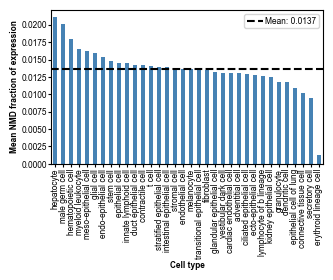

In [6]:
fig, ax = plt.subplots(figsize=(3.5, 2))
nmd_frac_s.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Mean NMD fraction of expression")
ax.set_xlabel("Cell type")
# ax.set_title("NMD isoform expression fraction per cell type")
ax.axhline(nmd_frac_s.mean(), color="black", linestyle="--",
           label=f"Mean: {nmd_frac_s.mean():.4f}")
ax.legend()
plt.xticks(rotation=90)
plt.savefig(figpath("03_03_nmd_fraction_per_celltype.pdf"))
plt.show()

#4. Per-tissue NMD fraction

In [7]:
tissues = sorted(adata.obs["tissue"].unique())
tissue_nmd_fracs = {}
for tissue in tissues:
    t_cells = (adata.obs["tissue"] == tissue).values
    if t_cells.sum() < 10:
        continue
    nmd_counts = np.array(adata.X[t_cells][:, nmd_mask].sum(axis=1)).ravel()
    total_counts = np.array(adata.X[t_cells].sum(axis=1)).ravel()
    nmd_frac = np.divide(nmd_counts, total_counts,
                          out=np.zeros_like(nmd_counts, dtype=float),
                          where=total_counts > 0)
    tissue_nmd_fracs[tissue] = nmd_frac.mean()

tissue_nmd_s = pd.Series(tissue_nmd_fracs).sort_values(ascending=False)


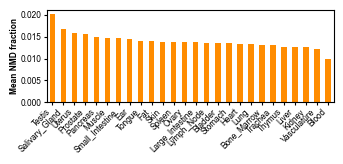

In [8]:
fig, ax = plt.subplots(figsize=(3.7, 1.2))
tissue_nmd_s.plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Mean NMD fraction")
# ax.set_title("NMD isoform expression fraction per tissue")
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_03_nmd_fraction_per_tissue.pdf"))
plt.show()

#5. Genes with high NMD isoform usage in specific cell types

In [9]:
gene_col = "pigeon_associated_gene" if "pigeon_associated_gene" in adata.var.columns else "gene_name"

# For each gene, compute the fraction of expression from NMD isoforms per cell type
genes = adata.var[gene_col].values
gene_to_cols = {}
for idx, g in enumerate(genes):
    gene_to_cols.setdefault(g, []).append(idx)

# Find genes with NMD isoforms
genes_with_nmd = [g for g, cols in gene_to_cols.items()
                  if any(nmd_mask[c] for c in cols) and len(cols) >= 2]
print(f"Genes with both NMD and non-NMD isoforms: {len(genes_with_nmd)}")

# Compute per-gene NMD fraction per cell type (sample a subset of genes)
nmd_gene_records = []
for gene in genes_with_nmd[:500]:  # limit for performance
    cols = gene_to_cols[gene]
    gene_nmd_cols = [c for c in cols if nmd_mask[c]]
    gene_non_nmd_cols = [c for c in cols if not nmd_mask[c]]
    if not gene_nmd_cols or not gene_non_nmd_cols:
        continue

    # `cell_types` is built from broad_cell_class, so the mask must use that column too.
    # Masking cell_ontology_class here silently matched zero cells for the 13 of 40 broad
    # names with no fine equivalent, and for the rest selected a fine cell type that merely
    # shared a name with the broad class.
    for ct in cell_types[:20]:  # top cell types
        ct_cells = (adata.obs["broad_cell_class"] == ct).values
        if ct_cells.sum() < 20:
            continue
        nmd_expr = np.array(adata.X[ct_cells][:, gene_nmd_cols].sum(axis=1)).ravel()
        total_expr = np.array(adata.X[ct_cells][:, cols].sum(axis=1)).ravel()
        expressed = total_expr > 0
        if expressed.sum() < 10:
            continue
        gene_nmd_frac = np.mean(nmd_expr[expressed] / total_expr[expressed])
        nmd_gene_records.append({"gene": gene, "cell_ontology_class": ct, "nmd_fraction": gene_nmd_frac})

nmd_gene_df = pd.DataFrame(nmd_gene_records)
if len(nmd_gene_df) > 0:
    # Top genes with highest NMD usage in any cell type
    top_nmd_genes = nmd_gene_df.sort_values("nmd_fraction", ascending=False).head(20)
    print("\nTop gene-celltype pairs by NMD isoform fraction:")
    print(top_nmd_genes.to_string(index=False))

Genes with both NMD and non-NMD isoforms: 8832

Top gene-celltype pairs by NMD isoform fraction:
    gene       cell_ontology_class  nmd_fraction
EEF1A1P5        hematopoietic cell      1.000000
  PHB1P7                fibroblast      1.000000
   RRAGA        hematopoietic cell      1.000000
   RRAGA glandular epithelial cell      1.000000
   NAIF1      duct epithelial cell      1.000000
EEF1A1P5                hepatocyte      1.000000
 TMEM250  ciliated epithelial cell      1.000000
EEF1A1P5            dendritic cell      1.000000
   RRAGA      innate lymphoid cell      1.000000
   RRAGA      endo-epithelial cell      1.000000
   RRAGA      duct epithelial cell      1.000000
   RRAGA          endothelial cell      0.999321
EEF1A1P5          contractile cell      0.998222
   RRAGA           epithelial cell      0.998145
EEF1A1P5      duct epithelial cell      0.998031
EEF1A1P5               granulocyte      0.997758
EEF1A1P5      endo-epithelial cell      0.997753
EEF1A1P5      innate 

#6. Coding vs non-coding isoform ratio by cell type and tissue

In [10]:
coding_mask = adata.var["is_coding"].values

# Per cell type
ct_coding_ratio = {}
# `cell_types` is built from broad_cell_class, so the mask must use that column too.
# Masking cell_ontology_class here silently matched zero cells for the 13 of 40 broad
# names with no fine equivalent, and for the rest selected a fine cell type that merely
# shared a name with the broad class.
for ct in cell_types:
    ct_cells = (adata.obs["broad_cell_class"] == ct).values
    if ct_cells.sum() < 10:
        continue
    coding_counts = np.array(adata.X[ct_cells][:, coding_mask].sum(axis=1)).ravel()
    total_counts = np.array(adata.X[ct_cells].sum(axis=1)).ravel()
    coding_frac = np.divide(coding_counts, total_counts,
                             out=np.zeros_like(coding_counts, dtype=float),
                             where=total_counts > 0)
    ct_coding_ratio[ct] = coding_frac.mean()

coding_s = pd.Series(ct_coding_ratio).sort_values(ascending=False)

# Per tissue
tissue_coding = {}
for tissue in tissues:
    t_cells = (adata.obs["tissue"] == tissue).values
    if t_cells.sum() < 10:
        continue
    coding_counts = np.array(adata.X[t_cells][:, coding_mask].sum(axis=1)).ravel()
    total_counts = np.array(adata.X[t_cells].sum(axis=1)).ravel()
    coding_frac = np.divide(coding_counts, total_counts,
                             out=np.zeros_like(coding_counts, dtype=float),
                             where=total_counts > 0)
    tissue_coding[tissue] = coding_frac.mean()

tissue_coding_s = pd.Series(tissue_coding).sort_values(ascending=False)

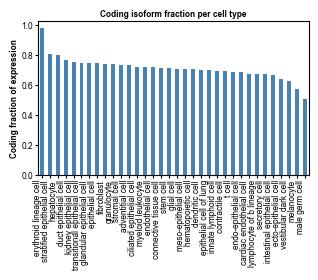

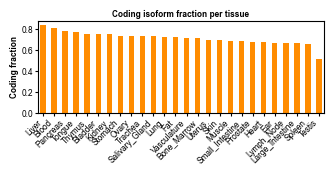

In [11]:
fig, ax = plt.subplots(figsize=(3.5, 2))
coding_s.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Coding fraction of expression")
ax.set_title("Coding isoform fraction per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
plt.savefig(figpath("03_03_coding_fraction_per_celltype.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(3.7, 1.2))
tissue_coding_s.plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Coding fraction")
ax.set_title("Coding isoform fraction per tissue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.savefig(figpath("03_03_coding_fraction_per_tissue.pdf"))
plt.show()


#7. Multi-isoform genes: cell type preferences for coding vs non-coding

In [12]:
# For genes with both coding and non-coding isoforms, compare coding fraction across cell types
genes_mixed_coding = [g for g, cols in gene_to_cols.items()
                      if any(coding_mask[c] for c in cols) and any(not coding_mask[c] for c in cols)
                      and len(cols) >= 2]
print(f"Genes with both coding and non-coding isoforms: {len(genes_mixed_coding)}")

# Compute per-gene coding fraction per cell type for a subset
coding_switch_records = []
for gene in genes_mixed_coding[:500]:
    cols = gene_to_cols[gene]
    gene_coding_cols = [c for c in cols if coding_mask[c]]

    ct_coding_fracs = []
    # `cell_types` is built from broad_cell_class, so the mask must use that column too.
    # Masking cell_ontology_class here silently matched zero cells for the 13 of 40 broad
    # names with no fine equivalent, and for the rest selected a fine cell type that merely
    # shared a name with the broad class.
    for ct in cell_types[:20]:
        ct_cells = (adata.obs["broad_cell_class"] == ct).values
        if ct_cells.sum() < 20:
            continue
        coding_expr = np.array(adata.X[ct_cells][:, gene_coding_cols].sum(axis=1)).ravel()
        total_expr = np.array(adata.X[ct_cells][:, cols].sum(axis=1)).ravel()
        expressed = total_expr > 0
        if expressed.sum() < 10:
            continue
        frac = np.mean(coding_expr[expressed] / total_expr[expressed])
        ct_coding_fracs.append(frac)

    if len(ct_coding_fracs) >= 3:
        coding_switch_records.append({
            "gene": gene,
            "coding_frac_var": np.var(ct_coding_fracs),
            "coding_frac_range": max(ct_coding_fracs) - min(ct_coding_fracs),
        })

switch_df = pd.DataFrame(coding_switch_records).sort_values("coding_frac_var", ascending=False)
print("\nTop genes with most variable coding/non-coding preference across cell types:")
print(switch_df.head(20).to_string(index=False))

Genes with both coding and non-coding isoforms: 19146

Top genes with most variable coding/non-coding preference across cell types:
           gene  coding_frac_var  coding_frac_range
         GARIN4         0.113840           0.977273
        TCEA1P4         0.112284           1.000000
        EIF4BP3         0.110551           0.814035
ENSG00000226036         0.107755           0.745098
         CFAP95         0.099715           0.831197
ENSG00000225489         0.094930           0.696133
           GAS1         0.072237           0.877193
      FLVCR1-DT         0.064596           0.888889
        C9orf24         0.057045           0.806428
         ZNF707         0.056515           0.688889
        MFSD14B         0.052489           0.968553
        BMS1P10         0.042913           0.683333
     UBQLN1-AS1         0.042639           0.692308
        SPATA6L         0.040997           0.840000
            CA9         0.038049           0.546888
       ADAMTSL1         0.034500    

#8. ORF length distributions for novel vs known

In [13]:
# ORF/CDS data now comes from SQANTI3 classification (loaded into adata.var)
cls_all = adata.var[["pigeon_structural_category", "sqanti_ORF_length", "sqanti_CDS_length", "sqanti_coding"]].copy()
cls_all["sqanti_ORF_length"] = pd.to_numeric(cls_all["sqanti_ORF_length"], errors="coerce")
cls_all["sqanti_CDS_length"] = pd.to_numeric(cls_all["sqanti_CDS_length"], errors="coerce")

known_cats = {"full-splice_match", "incomplete-splice_match"}
novel_cats = {"novel_in_catalog", "novel_not_in_catalog"}

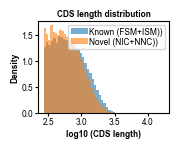

In [14]:
fig, ax = plt.subplots(figsize=(1.7, 1.2))
for label, cats in [("Known (FSM+ISM)", known_cats), ("Novel (NIC+NNC)", novel_cats)]:
    mask = cls_all["pigeon_structural_category"].isin(cats) & cls_all["sqanti_CDS_length"].notna() & (cls_all["sqanti_CDS_length"] > 0)
# NB gate on CDS_length, not ORF_length: SQANTI3 populated ORF_length with the CDS
# GENOMIC span (verified: ORF_length == CDS_genomic_end - CDS_genomic_start for 100%
# of coding isoforms), so it includes introns and exceeds the transcript length for
# 92% of multi-exon isoforms. CDS_length is the spliced coding length and is intact.
    if mask.sum() > 0:
        ax.hist(np.log10(cls_all.loc[mask, "sqanti_CDS_length"]), bins=50, alpha=0.6,
                label=f"{label})", density=True)
ax.set_xlabel("log10 (CDS length)")
ax.set_ylabel("Density")
ax.set_title("CDS length distribution")
ax.legend()
plt.savefig(figpath("03_03_orf_length_known_vs_novel.pdf"))
plt.show()

#9. NMD prediction by structural category

In [15]:
nmd_by_cat = None
nmd_by_coding = None
if "pigeon_structural_category" in adata.var.columns:
    nmd_by_cat = pd.crosstab(adata.var["pigeon_structural_category"], adata.var["is_NMD"], normalize="index")
    print("NMD fraction by structural category:")
    print(nmd_by_cat)

    # Also show NMD by coding status
    nmd_by_coding = pd.crosstab(adata.var["is_coding"], adata.var["is_NMD"], normalize="index")
    print("\nNMD by coding status:")
    print(nmd_by_coding)
else:
    print("structural_category not in adata.var")

NMD fraction by structural category:
is_NMD                         False     True 
pigeon_structural_category                    
antisense                   0.959459  0.040541
full-splice_match           0.973590  0.026410
fusion                      0.902959  0.097041
genic                       0.952025  0.047975
incomplete-splice_match     0.990614  0.009386
intergenic                  0.910868  0.089132
moreJunctions               0.873418  0.126582
novel_in_catalog            0.883241  0.116759
novel_not_in_catalog        0.922870  0.077130

NMD by coding status:
is_NMD        False     True 
is_coding                    
False      1.000000  0.000000
True       0.936983  0.063017


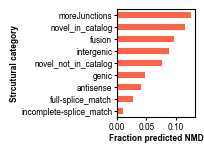

In [16]:
if nmd_by_cat is not None:
    fig, ax = plt.subplots(figsize=(1.0, 1.4))
    if True in nmd_by_cat.columns:
        nmd_by_cat[True].sort_values(ascending=True).plot(kind="barh", ax=ax, color="tomato")
    ax.set_xlabel("Fraction predicted NMD")
    ax.set_ylabel("Strcutural category")
    # ax.set_title("NMD prediction rate by structural category")
    # plt.xticks(rotation=45, ha="right")
    plt.savefig(figpath("03_03_nmd_rate_by_structural_category.pdf"))
    plt.show()

In [17]:
nmd_by_coding2 = None
if "pigeon_structural_category" in adata.var.columns:
    nmd_by_coding2 = pd.crosstab(adata.var["is_coding"], adata.var["is_NMD"], normalize="index")
    print("\nNMD by coding status:")
    print(nmd_by_coding2)
else:
    print("structural_category not in adata.var")



NMD by coding status:
is_NMD        False     True 
is_coding                    
False      1.000000  0.000000
True       0.936983  0.063017


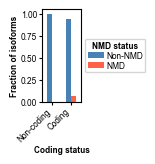

In [18]:
if nmd_by_coding2 is not None:
    fig, ax = plt.subplots(figsize=(0.5, 1.2))
    nmd_by_coding2.plot(kind="bar", ax=ax, color=["steelblue", "tomato"])
    # ax.set_yscale("log")
    ax.set_xlabel("Coding status")
    ax.set_ylabel("Fraction of isoforms")
    # ax.set_title("NMD prediction rate by coding status")
    ax.set_xticklabels(["Non-coding", "Coding"], rotation=45, ha = "right")
    ax.legend(["Non-NMD", "NMD"], title="NMD status", loc = 6, bbox_to_anchor = (1.0, 0.5))
    plt.savefig(figpath("03_03_nmd_rate_by_coding_status.pdf"))
    plt.show()

#10. Coding potential by gene biotype

In [19]:
# Load gene biotype annotations from GENCODE
biotypes_df = pd.read_csv("./../csvs/transcripts_to_genes_with_biotypes.txt", sep="\t")

# Strip version numbers from gene_id for matching
biotypes_gene = biotypes_df.drop_duplicates(subset="gene_id")[["gene_id", "gene_name", "gene_biotype"]].copy()
biotypes_gene["gene_id_noversion"] = biotypes_gene["gene_id"].str.replace(r"\.\d+$", "", regex=True)

# Map gene biotype to adata.var via gene_ids (which may have versions) or gene_name
# Try matching on gene_ids first
gene_ids_in_var = adata.var["gene_ids"].astype(str)
gene_id_to_biotype = dict(zip(biotypes_gene["gene_id"], biotypes_gene["gene_biotype"]))
gene_id_noversion_to_biotype = dict(zip(biotypes_gene["gene_id_noversion"], biotypes_gene["gene_biotype"]))
gene_name_to_biotype = dict(zip(biotypes_gene["gene_name"], biotypes_gene["gene_biotype"]))

# Try versioned gene_id first, then unversioned, then gene_name
adata.var["gene_biotype"] = gene_ids_in_var.map(gene_id_to_biotype)
unmapped = adata.var["gene_biotype"].isna()
if unmapped.any():
    gene_ids_noversion = gene_ids_in_var.str.replace(r"\.\d+$", "", regex=True)
    adata.var.loc[unmapped, "gene_biotype"] = gene_ids_noversion[unmapped].map(gene_id_noversion_to_biotype)
unmapped = adata.var["gene_biotype"].isna()
if unmapped.any():
    adata.var.loc[unmapped, "gene_biotype"] = adata.var.loc[unmapped, "gene_name"].map(gene_name_to_biotype)

mapped = adata.var["gene_biotype"].notna().sum()
print(f"Gene biotype mapped: {mapped} / {adata.n_vars} ({mapped/adata.n_vars:.1%})")
print(f"\nIsoform counts by gene biotype:")
print(adata.var["gene_biotype"].value_counts().head(15))

Gene biotype mapped: 847444 / 854410 (99.2%)

Isoform counts by gene biotype:
gene_biotype
protein_coding                        751943
lncRNA                                 70941
transcribed_unprocessed_pseudogene     10587
processed_pseudogene                    4466
unprocessed_pseudogene                  2213
transcribed_unitary_pseudogene          1843
TEC                                     1833
transcribed_processed_pseudogene        1630
misc_RNA                                 656
artifact                                 335
IG_C_gene                                294
TR_C_gene                                202
IG_V_gene                                162
TR_V_gene                                120
snoRNA                                    68
Name: count, dtype: int64


In [20]:
# Coding potential breakdown by gene biotype
biotype_coding = pd.crosstab(adata.var["gene_biotype"], adata.var["is_coding"], margins=True)
biotype_coding.columns = ["Non-coding", "Coding", "Total"]
biotype_coding["Coding fraction"] = biotype_coding["Coding"] / biotype_coding["Total"]
biotype_coding = biotype_coding.sort_values("Total", ascending=True)
print("Coding potential by gene biotype:")
print(biotype_coding.head(15).to_string())

# Plot coding fraction by gene biotype (top biotypes with >= 50 isoforms)
biotype_frac = biotype_coding[biotype_coding["Total"] >= 50].drop("All", errors="ignore")
biotype_frac = biotype_frac.sort_values("Coding fraction", ascending=True)


Coding potential by gene biotype:
                                   Non-coding  Coding  Total  Coding fraction
gene_biotype                                                                 
translated_processed_pseudogene             0       1      1         1.000000
scRNA                                       1       1      2         0.500000
snRNA                                       2       0      2         0.000000
ribozyme                                    3       0      3         0.000000
scaRNA                                      5       2      7         0.285714
IG_C_pseudogene                             8       5     13         0.384615
translated_unprocessed_pseudogene           7       9     16         0.562500
TR_V_pseudogene                            14       6     20         0.300000
IG_V_pseudogene                            27       8     35         0.228571
unitary_pseudogene                         27      25     52         0.480769
snoRNA                        

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


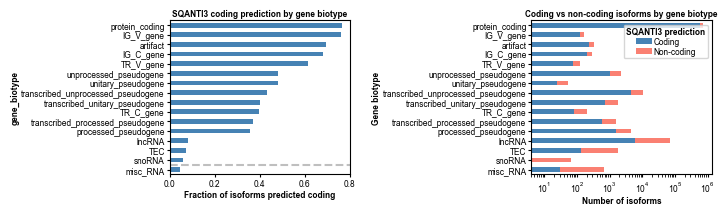

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2))

# Left: coding fraction
biotype_frac["Coding fraction"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Fraction of isoforms predicted coding")
axes[1].set_ylabel("Gene biotype")
axes[0].set_title("SQANTI3 coding prediction by gene biotype")
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)

# Right: stacked counts
biotype_frac[["Coding", "Non-coding"]].plot(kind="barh", stacked=True, ax=axes[1],
                                              color=["steelblue", "salmon"])
axes[1].set_xlabel("Number of isoforms")
axes[1].set_ylabel("Gene biotype")
axes[1].set_xscale("log")
axes[1].set_title("Coding vs non-coding isoforms by gene biotype")
# axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].legend(title="SQANTI3 prediction")

plt.subplots_adjust(wspace = 1.0)
plt.savefig(figpath("03_03_coding_by_gene_biotype.pdf"))
plt.show()


In [22]:
# NMD prediction rate by gene biotype
biotype_nmd = pd.crosstab(adata.var["gene_biotype"], adata.var["is_NMD"], margins=True)
biotype_nmd.columns = ["Non-NMD", "NMD", "Total"]
biotype_nmd["NMD fraction"] = biotype_nmd["NMD"] / biotype_nmd["Total"]
biotype_nmd = biotype_nmd.sort_values("Total", ascending=False)
print("NMD prediction by gene biotype:")
print(biotype_nmd.head(15).to_string())

# Plot NMD fraction for biotypes with >= 50 isoforms
biotype_nmd_frac = biotype_nmd[biotype_nmd["Total"] >= 50].drop("All", errors="ignore")
biotype_nmd_frac = biotype_nmd_frac.sort_values("NMD fraction", ascending=True)

NMD prediction by gene biotype:
                                    Non-NMD    NMD   Total  NMD fraction
gene_biotype                                                            
All                                  810663  36781  847444      0.043402
protein_coding                       718119  33824  751943      0.044982
lncRNA                                69740   1201   70941      0.016930
transcribed_unprocessed_pseudogene     9489   1098   10587      0.103712
processed_pseudogene                   4331    135    4466      0.030228
unprocessed_pseudogene                 2026    187    2213      0.084501
transcribed_unitary_pseudogene         1646    197    1843      0.106891
TEC                                    1811     22    1833      0.012002
transcribed_processed_pseudogene       1562     68    1630      0.041718
misc_RNA                                651      5     656      0.007622
artifact                                328      7     335      0.020896
IG_C_gene          

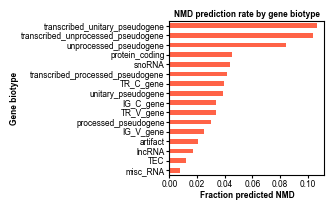

In [23]:
fig, ax = plt.subplots(figsize=(2, 2))
biotype_nmd_frac["NMD fraction"].plot(kind="barh", ax=ax, color="tomato")
ax.set_xlabel("Fraction predicted NMD")
ax.set_ylabel("Gene biotype")
ax.set_title("NMD prediction rate by gene biotype")
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.savefig(figpath("03_03_nmd_rate_by_gene_biotype.pdf"))
plt.show()


## 11. Single-cell strength: NMD burden across cell types, reproduced across donors

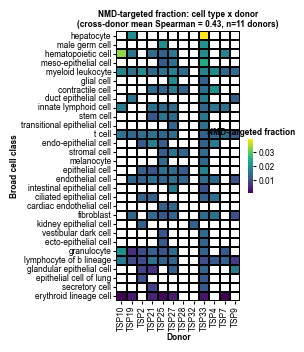

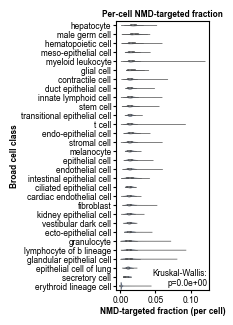

[NMD-targeted] cross-donor mean pairwise Spearman = 0.432 over 11 donors x 30 broad cell classes


In [24]:

# Single-cell strength: NMD-targeted usage across cell types + cross-donor reproducibility.
# Two things a bulk long-read study cannot show and that this section makes explicit:
#   (1) the PER-CELL distribution of NMD-targeted usage across cell types (single-cell resolution), and
#   (2) that the cell-type pattern REPRODUCES across independent donors (multi-donor robustness).
# Efficient: two full-matrix reductions -> per-cell fractions -> cheap groupby (tractable on the
# 16.7M-isoform object). Run on a bigmem node.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr, kruskal
from itertools import combinations

feat_mask = adata.var["is_NMD"].values if "is_NMD" in adata.var.columns else None
_ok = (feat_mask is not None) and bool(feat_mask.sum() > 0)
LABEL = "NMD-targeted"

if not _ok:
    print("Skipping NMD-targeted single-cell/cross-donor section - required feature/column not available.")
else:
    _A = adata
    _tot  = np.asarray(_A.X.sum(axis=1)).ravel().astype(float)
    _feat = np.asarray(_A.X[:, feat_mask].sum(axis=1)).ravel().astype(float)
    _frac = np.divide(_feat, _tot, out=np.zeros_like(_feat), where=_tot > 0)

    cell_df = _A.obs[["donor", "broad_cell_class", "cell_ontology_class"]].astype(str).copy()
    cell_df["frac"] = _frac
    cell_df = cell_df[(cell_df["broad_cell_class"] != "unknown") & (_tot > 0)]

    # (A) mean fraction per (broad_cell_class x donor); keep combos with >= 20 cells
    combo = (cell_df.groupby(["broad_cell_class", "donor"], observed=True)["frac"]
                     .agg(["mean", "size"]).reset_index())
    combo = combo[combo["size"] >= 20]
    pivot = combo.pivot(index="broad_cell_class", columns="donor", values="mean")
    pivot = pivot[pivot.notna().sum(axis=1) >= 2]           # cell classes seen in >= 2 donors

    # (B) cross-donor reproducibility = mean pairwise Spearman of the cell-type profiles
    donors = [d for d in pivot.columns if pivot[d].notna().sum() >= 3]
    rhos = []
    for a, b in combinations(donors, 2):
        m = pivot[a].notna() & pivot[b].notna()
        if m.sum() >= 3:
            r, _ = spearmanr(pivot.loc[m, a], pivot.loc[m, b])
            if np.isfinite(r):
                rhos.append(r)
    mean_rho = float(np.mean(rhos)) if rhos else float("nan")
    order = pivot.mean(axis=1).sort_values(ascending=False).index.tolist()

    # preferred plot formatting
    _TICK_LEN  = globals().get("TICK_LEN", 2.0)
    _TICK_PAD  = globals().get("TICK_LABEL_PAD", 1.5)
    _TITLE_PAD = globals().get("PANEL_TITLE_PAD", 3.0)

    # ---- Figure 1: cell-type x donor heatmap (cross-donor reproducibility) ----
    fig1, ax1 = plt.subplots(figsize=(2.0, 3.5))
    sns.heatmap(pivot.loc[order], ax=ax1, cmap="viridis", linewidths=0.05, linecolor="black",
                cbar_kws={"shrink": 0.2, "aspect": 10.0})
    ax1.set_title(f"{LABEL} fraction: cell type x donor\n(cross-donor mean Spearman = {mean_rho:.2f}, n={len(donors)} donors)",
                  fontweight="bold", pad=_TITLE_PAD)
    ax1.set_xlabel("Donor", fontweight="bold")
    ax1.set_ylabel("Broad cell class", fontweight="bold")
    ax1.tick_params(length=_TICK_LEN, pad=_TICK_PAD)
    _cb = ax1.collections[0].colorbar
    _cb.ax.set_title(f"{LABEL} fraction", fontsize=6, fontweight="bold", pad=_TITLE_PAD)  # colorbar title on top
    _cb.ax.tick_params(labelsize=6, length=_TICK_LEN, pad=_TICK_PAD)
    fig1.savefig(figpath("03_03_singlecell_nmd_crossdonor_heatmap.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

    # ---- Figure 2: per-cell violin (single-cell distribution) ----
    vdf = cell_df[cell_df["broad_cell_class"].isin(order)].copy()
    if len(vdf) > 60000:
        vdf = vdf.sample(60000, random_state=0)
    fig2, ax2 = plt.subplots(figsize=(1.2, 3.5))
    sns.violinplot(data=vdf, y="broad_cell_class", x="frac", order=order, ax=ax2,
                   inner="box", cut=0, linewidth=0.25, color="#4c72b0")
    ax2.set_title(f"Per-cell {LABEL} fraction", fontweight="bold", pad=_TITLE_PAD)
    ax2.set_xlabel(f"{LABEL} fraction (per cell)", fontweight="bold")
    ax2.set_ylabel("Broad cell class")
    ax2.tick_params(length=_TICK_LEN, pad=_TICK_PAD)

    groups = [g["frac"].values for _, g in vdf.groupby("broad_cell_class", observed=True) if len(g) >= 20]
    if len(groups) >= 2:
        H, pkw = kruskal(*groups)
        ax2.annotate(f"Kruskal-Wallis:\np={pkw:.1e}", xy=(0.98, 0.01),
                     xycoords="axes fraction", ha="right", va="bottom", fontsize=6)

    fig2.savefig(figpath("03_03_singlecell_nmd_crossdonor_violin.pdf"), bbox_inches="tight", dpi=300)
    plt.show()
    print(f"[{LABEL}] cross-donor mean pairwise Spearman = {mean_rho:.3f} "
          f"over {len(donors)} donors x {len(order)} broad cell classes")
